# Spotify Song Recommendation System
Complete machine learning project using the provided Spotify dataset.

**Includes:**
- Data Loading
- Data Cleaning
- Exploratory Data Analysis (EDA)
- Feature Scaling
- PCA Visualization
- K-Means Clustering
- Cosine Similarity Recommendation System
- Model Saving

In [3]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import joblib

plt.style.use('ggplot')

## Load Dataset

In [4]:
# Load Dataset
df = pd.read_csv('/content/Spotify_Dataset_V3.csv', sep=';')

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (8720, 20)


,Rank,Title,Artists,Date,Danceability,Energy,Loudness,Speechiness,Acousticness,Instrumentalness,Valence,# of Artist,Artist (Ind.),# of Nationality,Nationality,Continent,Points (Total),Points (Ind for each Artist/Nat),id,Song URL
0,1,Ella Baila Sola,"Eslabon Armado, Peso Pluma",29/05/2023,0.668,0.758,-5176.0,0.033,0.483,0.000,0.834,Artist 1,Eslabon Armado,Nationality 1,Mexico,Latin-America,200,100.0,3qQbCzHBycnDpGskqOWY0E,https://open.spotify.com/track/3qQbCzHBycnDpGs...
1,1,Ella Baila Sola,"Eslabon Armado, Peso Pluma",29/05/2023,0.668,0.758,-5176.0,0.033,0.483,0.000,0.834,Artist 2,Peso Pluma,Nationality 2,Mexico,Latin-America,200,100.0,3qQbCzHBycnDpGskqOWY0E,https://open.spotify.com/track/3qQbCzHBycnDpGs...
2,2,WHERE SHE GOES,Bad Bunny,29/05/2023,0.652,0.800,-4019.0,0.061,0.143,0.629,0.234,Artist 1,Bad Bunny,Nationality 1,Puerto Rico,Latin-America,199,199.0,7ro0hRteUMfnOioTFI5TG1,https://open.spotify.com/track/7ro0hRteUMfnOio...
3,3,La Bebe - Remix,"Yng Lvcas, Peso Pluma",29/05/2023,0.812,0.479,-5678.0,0.333,0.213,0.000,0.559,Artist 1,Yng Lvcas,Nationality 1,Mexico,Latin-America,198,99.0,2UW7JaomAMuX9pZrjVpHAU,https://open.spotify.com/track/2UW7JaomAMuX9pZ...
4,3,La Bebe - Remix,"Yng Lvcas, Peso Pluma",29/05/2023,0.812,0.479,-5678.0,0.333,0.213,0.000,0.559,Artist 2,Peso Pluma,Nationality 2,Mexico,Latin-America,198,99.0,2UW7JaomAMuX9pZrjVpHAU,https://open.spotify.com/track/2UW7JaomAMuX9pZ...


## Data Cleaning

In [5]:
# Remove duplicate rows
df = df.drop_duplicates()

# Check missing values
print(df.isnull().sum())

# Fill numeric missing values if any
numeric_cols = df.select_dtypes(include=np.number).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

print("\nShape after removing duplicates:", df.shape)

Rank                                0
Title                               0
Artists                             0
Date                                0
Danceability                        0
Energy                              0
Loudness                            0
Speechiness                         0
Acousticness                        0
Instrumentalness                    0
Valence                             0
# of Artist                         0
Artist (Ind.)                       0
# of Nationality                    0
Nationality                         0
Continent                           0
Points (Total)                      0
Points (Ind for each Artist/Nat)    0
id                                  0
Song URL                            0
dtype: int64

Shape after removing duplicates: (8720, 20)


## Dataset Information

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8720 entries, 0 to 8719
Data columns (total 20 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Rank                              8720 non-null   int64  
 1   Title                             8720 non-null   object 
 2   Artists                           8720 non-null   object 
 3   Date                              8720 non-null   object 
 4   Danceability                      8720 non-null   float64
 5   Energy                            8720 non-null   float64
 6   Loudness                          8720 non-null   float64
 7   Speechiness                       8720 non-null   float64
 8   Acousticness                      8720 non-null   float64
 9   Instrumentalness                  8720 non-null   float64
 10  Valence                           8720 non-null   float64
 11  # of Artist                       8720 non-null   object 
 12  Artist

## Statistical Summary

In [7]:
df.describe()

,Rank,Danceability,Energy,Loudness,Speechiness,Acousticness,Instrumentalness,Valence,Points (Total),Points (Ind for each Artist/Nat)
count,8720.000000,8720.000000,8720.000000,8720.000000,8720.000000,8720.000000,8720.000000,8720.000000,8720.000000,8720.000000
mean,97.837156,0.672356,0.652136,-5156.151930,0.092617,0.235875,0.014083,0.517535,103.162844,69.302752
std,58.403427,0.130758,0.148296,2824.645106,0.092996,0.233815,0.087107,0.236522,58.403427,47.879326
min,1.000000,0.323000,0.192000,-16027.000000,0.023000,0.000000,0.000000,0.039000,1.000000,0.333333
25%,47.000000,0.571000,0.545000,-6944.000000,0.039000,0.050000,0.000000,0.344000,52.000000,30.000000
50%,97.000000,0.683000,0.661000,-5289.000000,0.054000,0.150000,0.000000,0.498000,104.000000,64.000000
75%,149.000000,0.778000,0.761000,-3894.000000,0.099000,0.355000,0.000000,0.698000,154.000000,94.000000
max,200.000000,0.954000,0.979000,-2.810000,0.637000,0.969000,0.901000,0.963000,200.000000,200.000000


## Feature Selection

In [8]:
features = [
    'Danceability',
    'Energy',
    'Loudness',
    'Speechiness',
    'Acousticness',
    'Instrumentalness',
    'Valence'
]

X = df[features]
X.head()

,Danceability,Energy,Loudness,Speechiness,Acousticness,Instrumentalness,Valence
0,0.668,0.758,-5176.0,0.033,0.483,0.000,0.834
1,0.668,0.758,-5176.0,0.033,0.483,0.000,0.834
2,0.652,0.800,-4019.0,0.061,0.143,0.629,0.234
3,0.812,0.479,-5678.0,0.333,0.213,0.000,0.559
4,0.812,0.479,-5678.0,0.333,0.213,0.000,0.559


## Correlation Heatmap

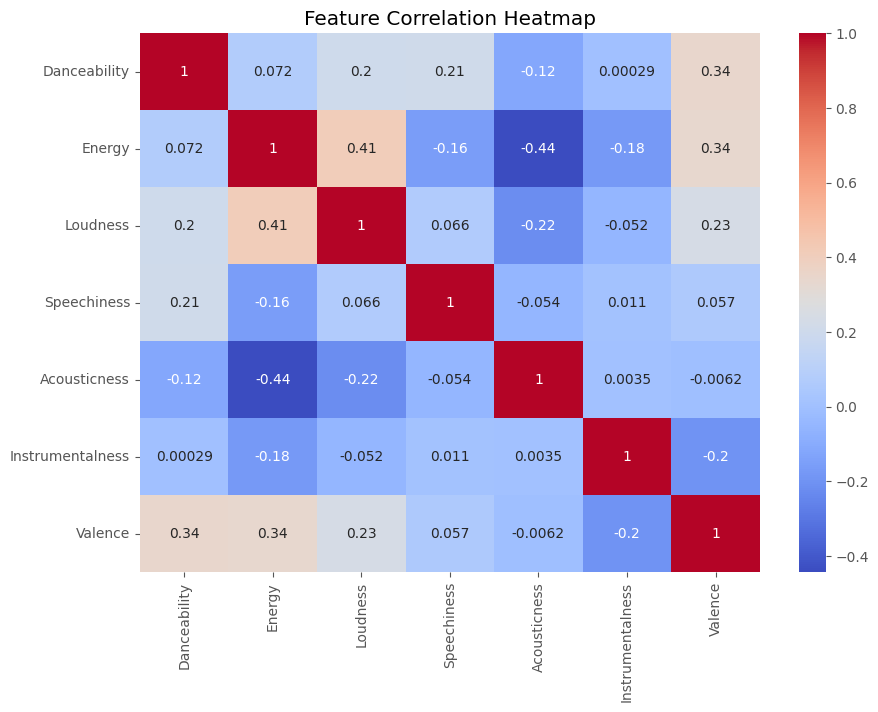

In [9]:
plt.figure(figsize=(10,7))
sns.heatmap(X.corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

## Feature Distributions

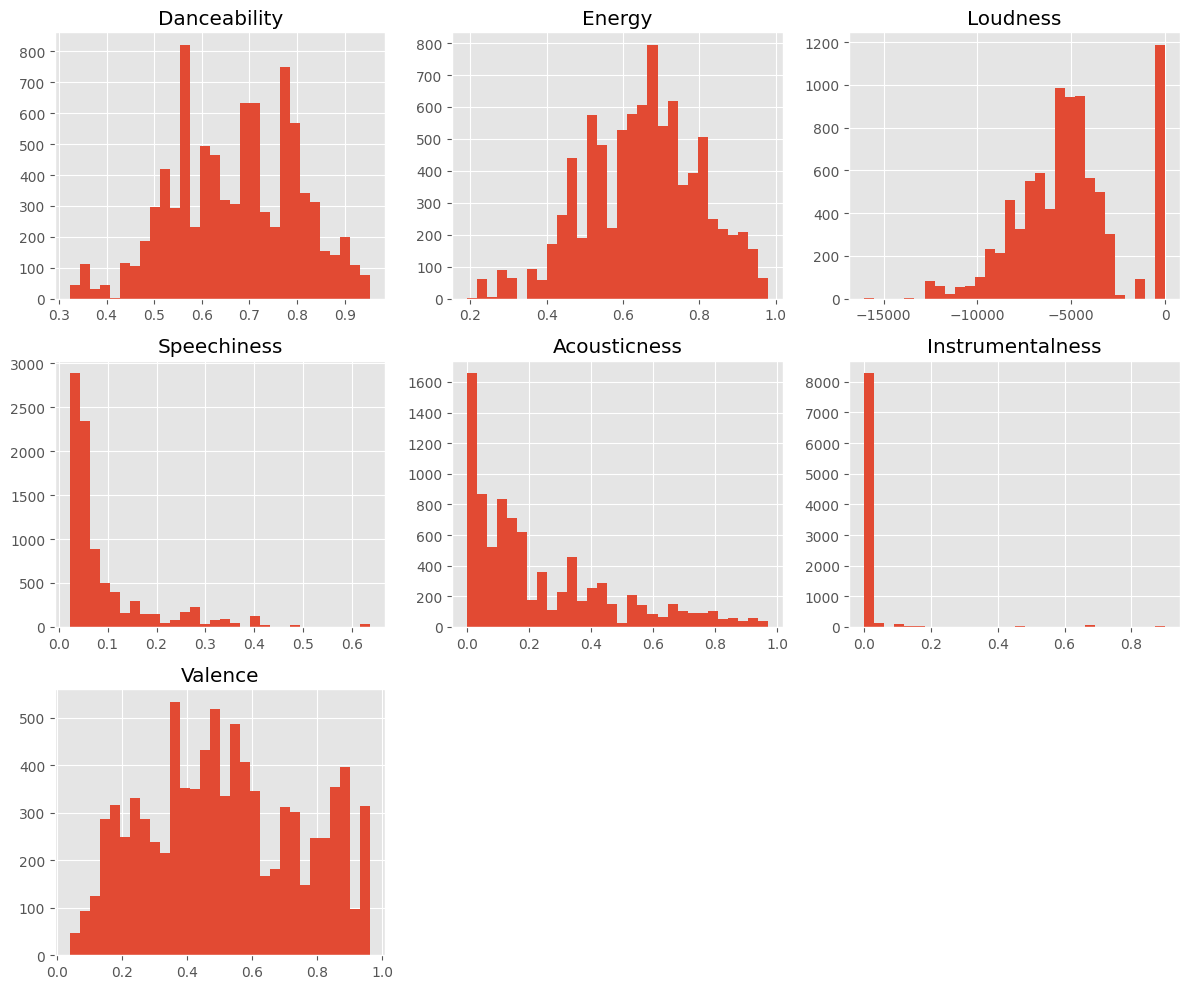

In [10]:
X.hist(figsize=(12,10), bins=30)
plt.tight_layout()
plt.show()

## Boxplots (Outlier Detection)

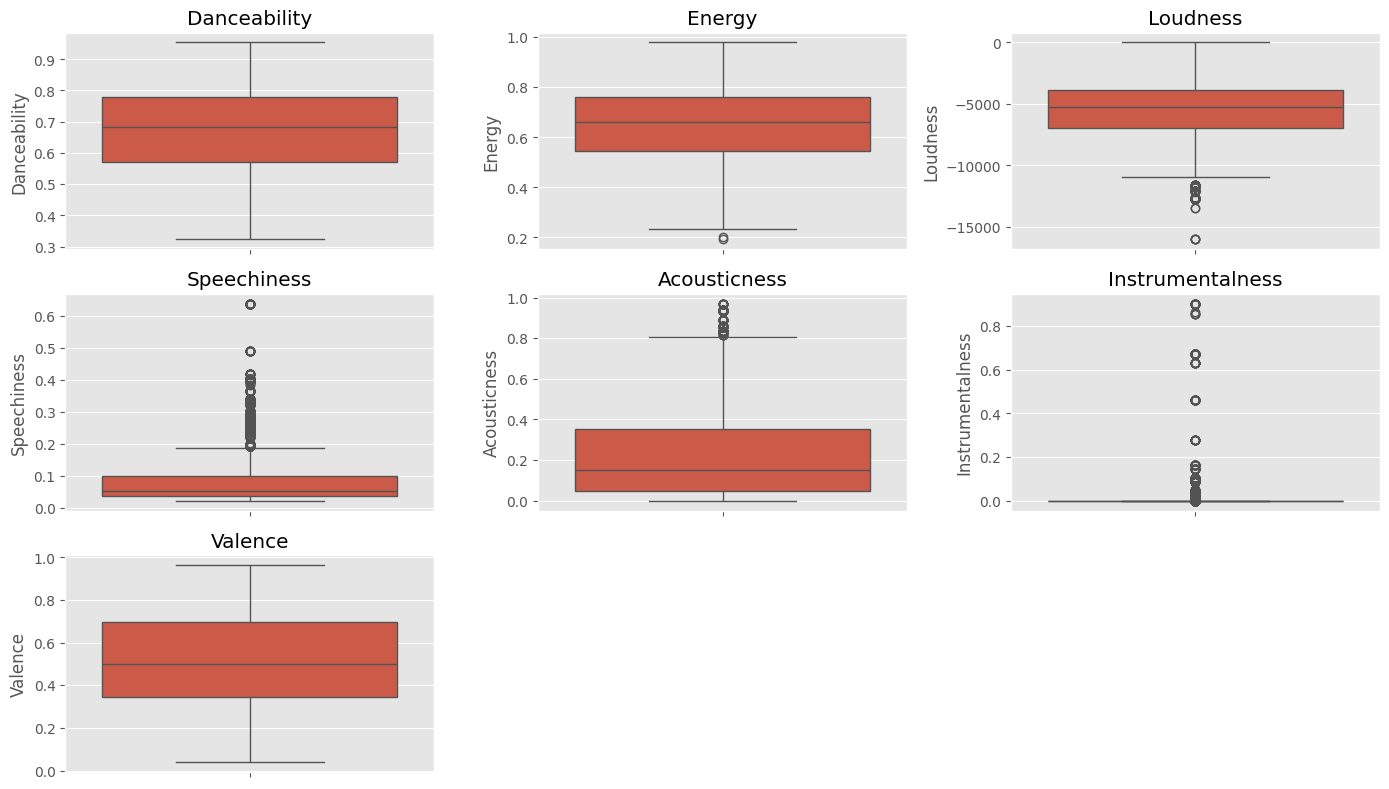

In [11]:
plt.figure(figsize=(14,8))
for i, col in enumerate(features, 1):
    plt.subplot(3,3,i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

## Feature Scaling

In [12]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled Feature Shape:", X_scaled.shape)

Scaled Feature Shape: (8720, 7)


## PCA (2D Visualization)

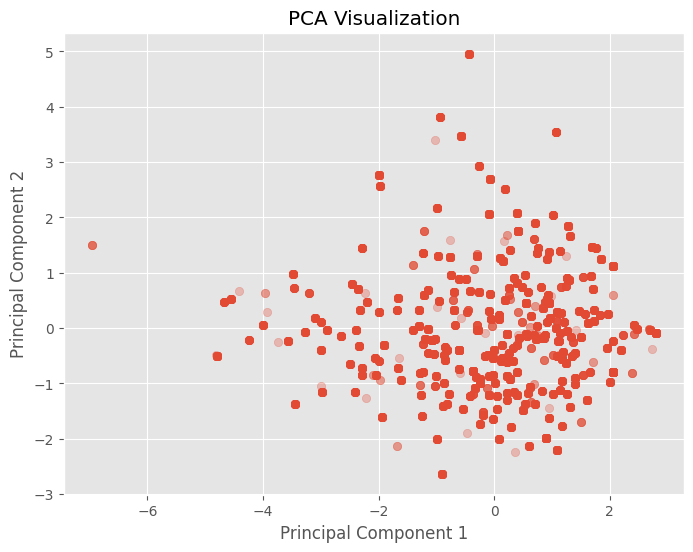

In [13]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    'PC1': pca_result[:,0],
    'PC2': pca_result[:,1]
})

plt.figure(figsize=(8,6))
plt.scatter(pca_df['PC1'], pca_df['PC2'], alpha=0.3)
plt.title('PCA Visualization')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

## K-Means Clustering

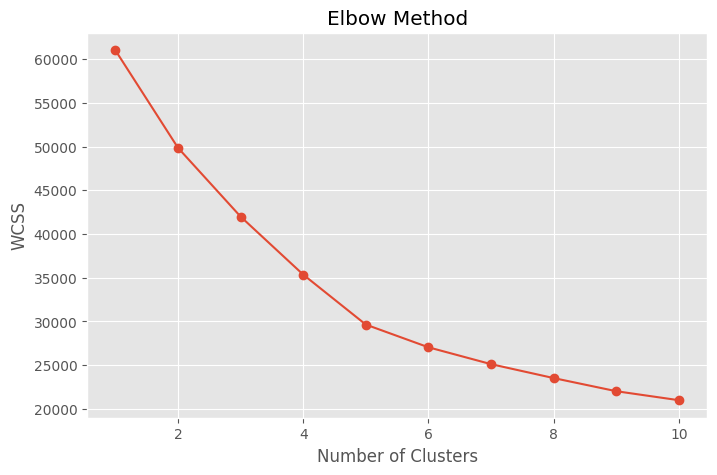

In [14]:
# Elbow Method
wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

In [15]:
# Train final KMeans model
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

print(df[['Title', 'Cluster']].head())

             Title  Cluster
0  Ella Baila Sola        1
1  Ella Baila Sola        1
2   WHERE SHE GOES        4
3  La Bebe - Remix        0
4  La Bebe - Remix        0


## Cosine Similarity Recommendation System

In [16]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity

X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

similarity = cosine_similarity(X_scaled)

print(similarity.shape)

(8720, 8720)


## Recommendation Function

In [17]:
def recommend(song_name, top_n=5):

    song = df[df['Title'].str.lower() == song_name.lower()]

    if song.empty:
        return "Song Not Found"

    index = song.index[0]

    distances = list(enumerate(similarity[index]))

    distances = sorted(
        distances,
        key=lambda x: x[1],
        reverse=True
    )[1:top_n+1]

    song_indices = [i[0] for i in distances]

    return df.loc[song_indices, ['Title', 'Artists', 'Cluster']]

## Example Recommendations

In [18]:
recommend('Ella Baila Sola', top_n=10)

,Title,Artists,Cluster
1,Ella Baila Sola,"Eslabon Armado, Peso Pluma",1
295,Ella Baila Sola,"Eslabon Armado, Peso Pluma",1
296,Ella Baila Sola,"Eslabon Armado, Peso Pluma",1
589,Ella Baila Sola,"Eslabon Armado, Peso Pluma",1
590,Ella Baila Sola,"Eslabon Armado, Peso Pluma",1
893,Ella Baila Sola,"Eslabon Armado, Peso Pluma",1
894,Ella Baila Sola,"Eslabon Armado, Peso Pluma",1
1190,Ella Baila Sola,"Eslabon Armado, Peso Pluma",1
1191,Ella Baila Sola,"Eslabon Armado, Peso Pluma",1
1478,Ella Baila Sola,"Eslabon Armado, Peso Pluma",1


## Save Model

In [19]:
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(kmeans, 'kmeans_model.pkl')

print("Models saved successfully!")

Models saved successfully!


## Save Cleaned Dataset

In [20]:
df.to_csv('spotify_cleaned.csv', index=False)

print("Cleaned dataset saved!")

Cleaned dataset saved!


## Project Summary
This notebook demonstrates a complete Spotify song recommendation system:

1. Loaded and cleaned the dataset.
2. Performed EDA and visualization.
3. Scaled numerical features.
4. Applied PCA for dimensionality reduction.
5. Clustered songs using K-Means.
6. Built a content-based recommendation engine using cosine similarity.
7. Saved the trained preprocessing objects for future use.